# Chapter 7 — Unsupervised Learning

## Learning Objectives

This notebook covers PCA, correspondence-style dimensional thinking, K-means clustering, hierarchical clustering, Gaussian mixture models, scaling, categorical variables, and cluster interpretation.

## Theoretical Explanation

Unsupervised learning finds structure without a target variable. PCA reduces dimensionality by finding directions of maximum variance. Clustering groups records by similarity. K-means is scalable and centroid-based. Hierarchical clustering builds nested groups and can be visualized with dendrograms. Model-based clustering assumes data is generated by a mixture of probability distributions.

Scaling is critical because unsupervised algorithms often rely on distances or variances. Variables with large numeric ranges can dominate results. Categorical variables require careful encoding, and mixed data often needs specialized distances such as Gower distance.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. PCA for Dimensionality Reduction

Explained variance ratio: [0.362 0.192]


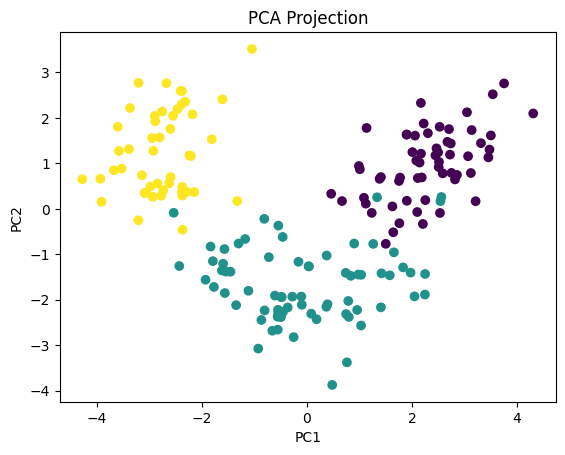

In [2]:
from sklearn.datasets import load_wine, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram

wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 3))
plt.scatter(X_pca[:,0], X_pca[:,1], c=wine.target, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection')
plt.show()

### Output Interpretation

The first two principal components summarize major variance directions. If classes separate in PCA space, important structure is captured by the projection.

## 2. K-Means and Number of Clusters

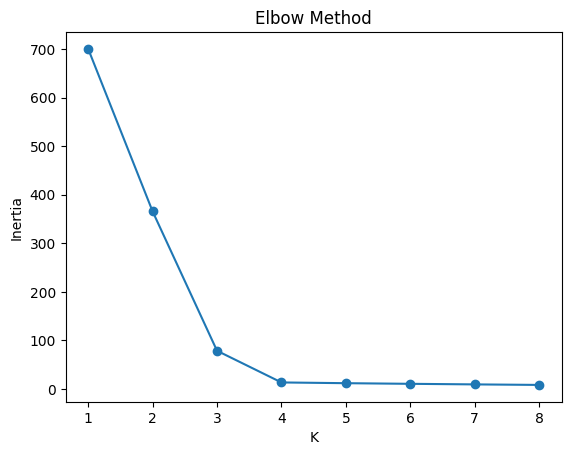

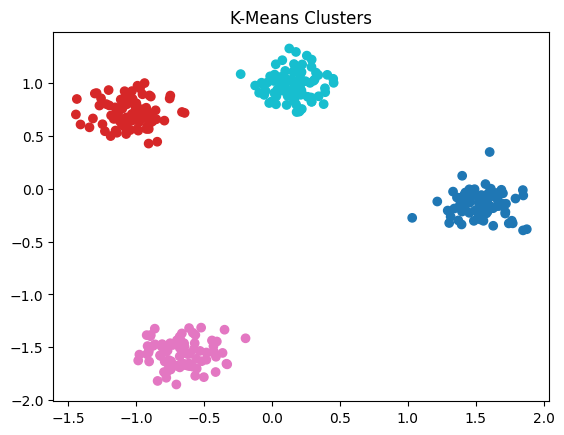

In [3]:
X_blobs, _ = make_blobs(n_samples=350, centers=4, cluster_std=0.8, random_state=RANDOM_STATE)
X_blobs = StandardScaler().fit_transform(X_blobs)
inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_blobs)
    inertias.append(km.inertia_)
plt.plot(range(1,9), inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
labels = km.fit_predict(X_blobs)
plt.scatter(X_blobs[:,0], X_blobs[:,1], c=labels, cmap='tab10')
plt.title('K-Means Clusters')
plt.show()

### Output Interpretation

The elbow plot helps inspect diminishing returns as K increases. The cluster plot shows centroid-based group assignments.

## 3. Hierarchical Clustering and Gaussian Mixture

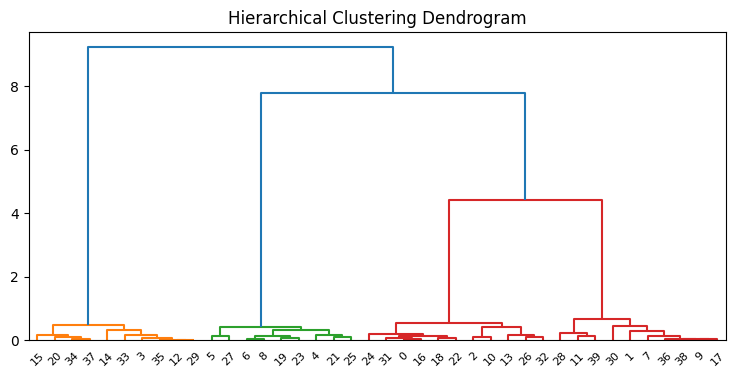

Gaussian mixture BIC: 306.35


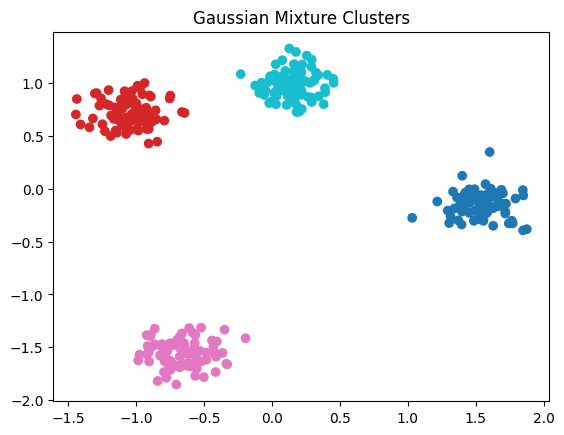

In [4]:
Z = linkage(X_blobs[:40], method='ward')
plt.figure(figsize=(9, 4))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_blobs)
print('Gaussian mixture BIC:', round(gmm.bic(X_blobs), 2))
plt.scatter(X_blobs[:,0], X_blobs[:,1], c=gmm_labels, cmap='tab10')
plt.title('Gaussian Mixture Clusters')
plt.show()

### Output Interpretation

The dendrogram visualizes nested merging of observations. The Gaussian mixture model assigns clusters based on probability distributions rather than only nearest centroids.

## Extended Study Notes

The most important professional habit in practical statistics is interpretation. A statistic is not useful only because it can be computed; it is useful when it answers a real question about data quality, uncertainty, relationships, prediction, or decision-making. In data science work, the same numerical result can have different meanings depending on the sampling process, the metric used, the business cost of errors, and the assumptions behind the procedure.

This notebook intentionally uses original, simplified examples instead of copying the book examples verbatim. The purpose is academic understanding: connect the statistical concept to a runnable Python workflow, inspect the output, and explain what the output means. This also supports academic integrity because the notebook demonstrates the learned concept in original wording and with adapted code.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, Python implementation, output interpretation, and practical data science context.

## Key Takeaways

- Statistical concepts should be connected to data science decisions, not treated as isolated formulas.
- Visual summaries and resampling methods often provide practical intuition beyond formula-based statistics.
- Model evaluation must consider uncertainty, bias, sampling, and the cost of incorrect conclusions.
- The output of code should always be interpreted in context before making decisions.